In [ ]:
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from env.py import EcommerceEnv, train_df, val_df

[EP   30] TrainR=-14.41  ValR=  4.66
[EP   60] TrainR= 66.18  ValR=  0.86
[EP   90] TrainR= 48.62  ValR=  4.41
[EP  120] TrainR= 38.80  ValR=  3.14
[EP  150] TrainR= 70.67  ValR=  4.49
[EP  180] TrainR= 60.30  ValR=  4.66
[EP  210] TrainR= 12.81  ValR=  5.09
[EP  240] TrainR= 63.32  ValR=  4.40
[EP  270] TrainR= 25.39  ValR=  4.55
[EP  300] TrainR= 50.87  ValR=  3.37
[EP  330] TrainR= 62.55  ValR=  4.00
[EP  360] TrainR=  2.31  ValR=  6.03
[EP  390] TrainR=-16.17  ValR=  5.39
[EP  420] TrainR= 53.36  ValR=  5.78
[EP  450] TrainR= 41.93  ValR=  4.36
[EP  480] TrainR= 58.51  ValR=  4.46

 Average Reward (16 points): 4.353


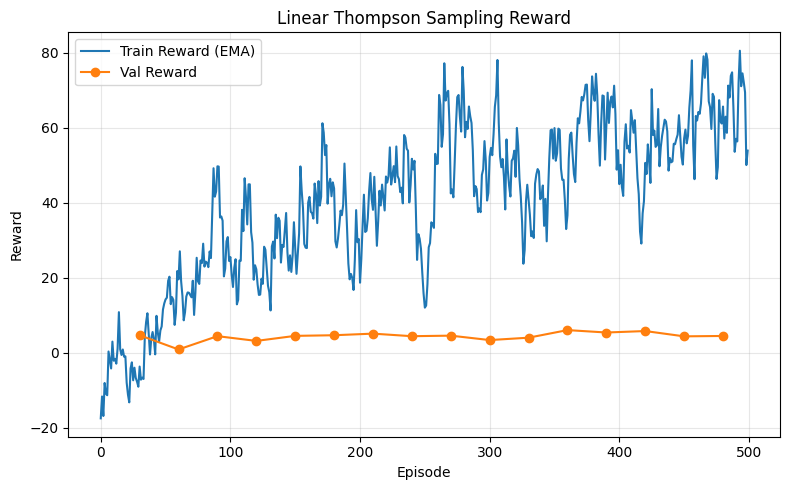

In [ ]:
# ===== CB Cell =====
device = torch.device('cpu')
# Policy Network
class CBPolicy(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return self.net(x)

# 2) State Flattening
def state_to_tensor(state, n_products):
    usr  = state["user"]
    hist = np.array(state["history"]) / n_products
    ctx  = state["context"]
    v    = np.concatenate([usr, hist, ctx]).astype(np.float32)
    return torch.from_numpy(v).to(device)

# Evaluation Function
@torch.no_grad()
def evaluate_agent(policy, env, episodes=50):
    policy.eval()
    rs = []
    for _ in range(episodes):
        s, done, ep_r = env.reset(), False, 0.0
        while not done:
            logits = policy(state_to_tensor(s, len(env.products))).unsqueeze(0)
            a = torch.argmax(logits, dim=-1).item()
            s, r, done, _ = env.step(a)
            ep_r += r
        rs.append(ep_r)
    policy.train()
    return float(np.mean(rs))

# 4) Modified LinUCB
# Core: LinTS Training Function
def train_lin_ts(
    train_env, val_env,
    episodes: int = 1000,
    v: float = 0.5,           # Noise strength of Thompson Sampling
    lam: float = 1.0,         # Forgetting factor
    eval_every: int = 50,
    val_episodes: int = 100
):
    obs_dim   = 10 + train_env.history_window + 3
    n_actions = len(train_env.products)

    # Initialize A=I, b=0
    A = [np.eye(obs_dim) for _ in range(n_actions)]
    b = [np.zeros(obs_dim) for _ in range(n_actions)]

    train_R, val_R = [], []
    xs = np.arange(eval_every, episodes+1, eval_every)

    for ep in range(1, episodes+1):
        s, done, ep_r = train_env.reset(), False, 0.0

        while not done:
            x = state_to_tensor(s, n_actions).cpu().numpy()

            # === Thompson Sampling: Sample theta_a ~ N(mu_a, v^2 * A^{-1}_a) for each arm ===
            thetas = []
            for a in range(n_actions):
                A_inv = np.linalg.inv(A[a])
                mu    = A_inv.dot(b[a])
                # Variance matrix = v^2 * A_inv
                noise = np.random.multivariate_normal(
                    mean=np.zeros(obs_dim),
                    cov=(v**2) * A_inv
                )
                thetas.append(mu + noise)
            # Compute scores and choose arm
            scores = [thetas[a].dot(x) for a in range(n_actions)]
            a_star = int(np.argmax(scores))

            # Take action
            s, r, done, _ = train_env.step(a_star)
            ep_r += r

            # Update A, b
            A[a_star] = lam * A[a_star] + np.outer(x, x)
            b[a_star] = lam * b[a_star] + r * x

        train_R.append(ep_r)

        # Periodic evaluation
        if ep % eval_every == 0:
            vs = []
            for _ in range(val_episodes):
                sv, dv, rv = val_env.reset(), False, 0.0
                while not dv:
                    xv = state_to_tensor(sv, n_actions).cpu().numpy()
                    # During evaluation, use mu (greedy)
                    ests = [np.linalg.inv(A[a]).dot(b[a]).dot(xv) for a in range(n_actions)]
                    av = int(np.argmax(ests))
                    sv, r_v, dv, _ = val_env.step(av)
                    rv += r_v
                vs.append(rv)
            avg_vr = float(np.mean(vs))
            val_R.append(avg_vr)
            print(f"[EP {ep:4d}] TrainR={ep_r:6.2f}  ValR={avg_vr:6.2f}")

    # Overall average
    print(f"\n Average Reward ({len(val_R)} points): {np.mean(val_R):.3f}")

    # Smoothing training curve (EMA)
    def ema(x, a=0.2):
        y = [x[0]]
        for xi in x[1:]:
            y.append(a*xi + (1-a)*y[-1])
        return np.array(y)

    train_R_s = ema(train_R)

    # Plotting
    plt.figure(figsize=(8,5))
    plt.plot(train_R_s,    label='Train Reward (EMA)')
    plt.plot(xs, val_R, 'o-', label='Val Reward')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Linear Thompson Sampling Reward')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return A, b

# Main
train_env = EcommerceEnv(train_df, history_window=5)
val_env   = EcommerceEnv(val_df,   history_window=5)
A_ts, b_ts = train_lin_ts(
    train_env, val_env,
    episodes=500,
    v=0.5,
    lam=1.0,
    eval_every=30,
    val_episodes=100
)


In [ ]:
import numpy as np
import torch

# Function to convert CB model parameters (A, b) into a scoring function
def make_linucb_score_fn(A, b):
    """
    Returns a function f(state) -> scores  (numpy array of length n_actions)
    """
    invA = [np.linalg.inv(Aa) for Aa in A]
    def score_fn(state, n_products):
        x = state_to_tensor(state, n_products).cpu().numpy()
        scores = np.array([invA[a].dot(b[a]).dot(x) for a in range(len(A))])
        return scores
    return score_fn

# Ranking evaluation function
def evaluate_ranking(score_fn, env, Ks=[1,5,10], episodes=500):
    """
    score_fn: (state_dict, n_products) -> ndarray scores
    env: your EcommerceEnv
    Ks: list of Top-K values to compute
    """
    # accumulators for hits and DCG for each K
    hits = {k: [] for k in Ks}
    ndcgs = {k: [] for k in Ks}

    for _ in range(episodes):
        state = env.reset()
        done = False
        while not done:
            # the “correct” action index from the actual interaction
            true_pid  = env.user_data.iloc[env._idx]['Product ID']
            true_idx  = env.product_to_idx[true_pid]

            # model scores all actions
            scores = score_fn(state, len(env.products))
            ranking = np.argsort(scores)[::-1]  # descending order

            # compute hit & ndcg for each K
            for k in Ks:
                topk = ranking[:k]
                if true_idx in topk:
                    hits[k].append(1)
                    rank_pos = np.where(topk == true_idx)[0][0]
                    ndcgs[k].append(1.0 / np.log2(rank_pos + 2))
                else:
                    hits[k].append(0)
                    ndcgs[k].append(0.0)

            # advance environment using the logged action
            state, _, done, _ = env.step(true_idx)

    # print results
    for k in Ks:
        hr  = np.mean(hits[k])
        ndc = np.mean(ndcgs[k])
        print(f"Top-{k}  HitRate: {hr:.3f}   NDCG: {ndc:.3f}")

# Main

# build a scoring function
score_fn = make_linucb_score_fn(A_ts, b_ts)

# evaluate Top-K on validation set
print("\n—— LinTS Top-K Ranking ——")
evaluate_ranking(score_fn, val_env, Ks=[1,3,5], episodes=100)




—— LinTS Top-K Ranking ——
Top-1  HitRate: 0.026   NDCG: 0.026
Top-3  HitRate: 0.073   NDCG: 0.052
Top-5  HitRate: 0.131   NDCG: 0.076
